## IMPORTING LIBRARIES AND DATASET

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('tennis.csv')
df = df.drop(columns=['No'])  # drop index column
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


## SEPERATING FEATURES AND TARGETS

In [3]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play Tennis']

print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
    Outlook Temperature Humidity    Wind
0     Sunny         Hot     High    Weak
1     Sunny         Hot     High  Strong
2  Overcast         Hot     High    Weak
3      Rain        Mild     High    Weak
4      Rain        Cool   Normal    Weak

Target:
0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: str


## ENCODING CATEGORICAL VALUES

In [4]:
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)

X_encoded_df = pd.DataFrame(X_encoded, columns=X.columns)
print("Encoded Features:")
print(X_encoded_df.head())

print("\nCategory mappings:")
for col, cats in zip(X.columns, encoder.categories_):
    print(f"{col}: {list(cats)}")

Encoded Features:
   Outlook  Temperature  Humidity  Wind
0      2.0          1.0       0.0   1.0
1      2.0          1.0       0.0   0.0
2      0.0          1.0       0.0   1.0
3      1.0          2.0       0.0   1.0
4      1.0          0.0       1.0   1.0

Category mappings:
Outlook: ['Overcast', 'Rain', 'Sunny']
Temperature: ['Cool', 'Hot', 'Mild']
Humidity: ['High', 'Normal']
Wind: ['Strong', 'Weak']


## TRAIN TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 35
Testing set size: 15


## TRAINING CATEGORICAL NAIVE BAYES

In [6]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print("Predictions:", y_pred_nb)
print("Actual     :", y_test.values)

Predictions: ['Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'No']
Actual     : <StringArray>
['Yes',  'No', 'Yes',  'No', 'Yes', 'Yes', 'Yes',  'No', 'Yes', 'Yes', 'Yes',
 'Yes',  'No', 'Yes',  'No']
Length: 15, dtype: str


## EVALUATING NAIVE BAYES

In [7]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8667

Confusion Matrix:
[[ 3  2]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15



## PREDICTING WEATHER CONDIDTIONS

In [8]:
new_data = pd.DataFrame({
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
})

new_encoded = encoder.transform(new_data)

prediction = nb_model.predict(new_encoded)
probability = nb_model.predict_proba(new_encoded)

print("Predicted Class:", prediction[0])
print("\nClass Probabilities:")
for cls, prob in zip(nb_model.classes_, probability[0]):
    print(f"{cls}: {prob:.4f}")

Predicted Class: No

Class Probabilities:
No: 0.7466
Yes: 0.2534


## TRAINING DECISION TREE

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

dt_pred_new = dt_model.predict(new_encoded)
print("Decision Tree prediction for new data:", dt_pred_new[0])

Decision Tree Accuracy: 1.0000

Confusion Matrix:
[[ 5  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00        10

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Decision Tree prediction for new data: No


## TRAINING LOGISTIC

In [10]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

lr_pred_new = lr_model.predict(new_encoded)
print("Logistic Regression prediction for new data:", lr_pred_new[0])

Logistic Regression Accuracy: 0.9333

Confusion Matrix:
[[ 4  1]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.80      0.89         5
         Yes       0.91      1.00      0.95        10

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15

Logistic Regression prediction for new data: No


## COMPARISON

In [11]:
comparison = pd.DataFrame({
    'Model': ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, dt_accuracy, lr_accuracy],
    'Prediction (Sunny, Cool, High, Strong)': [prediction[0], dt_pred_new[0], lr_pred_new[0]]
})

print(comparison.to_string(index=False))

                  Model  Accuracy Prediction (Sunny, Cool, High, Strong)
Categorical Naive Bayes  0.866667                                     No
          Decision Tree  1.000000                                     No
    Logistic Regression  0.933333                                     No


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

sns.set_style("whitegrid")

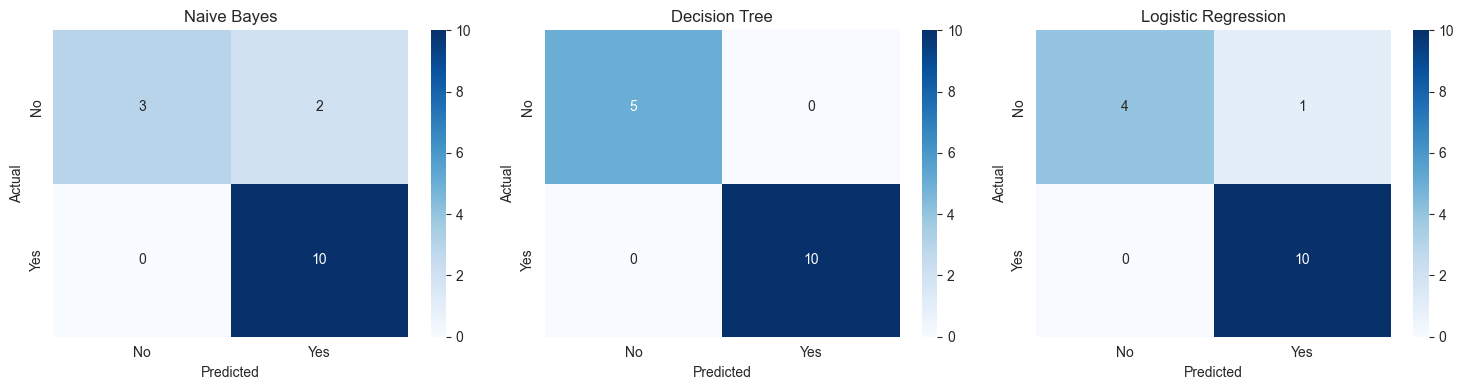

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_preds = [
    ("Naive Bayes", y_pred_nb),
    ("Decision Tree", y_pred_dt),
    ("Logistic Regression", y_pred_lr)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds, labels=nb_model.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nb_model.classes_, yticklabels=nb_model.classes_, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

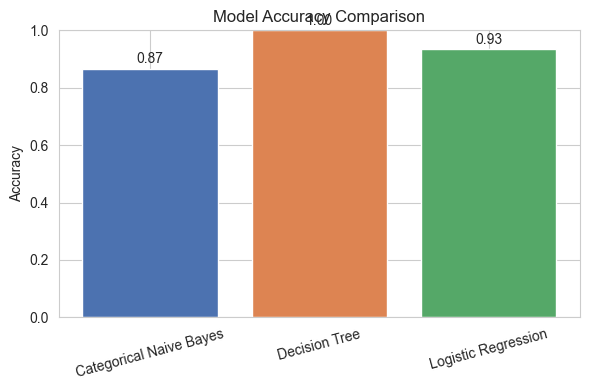

In [14]:
plt.figure(figsize=(6, 4))
bars = plt.bar(comparison['Model'], comparison['Accuracy'],
                color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar, acc in zip(bars, comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f"{acc:.2f}", ha='center')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

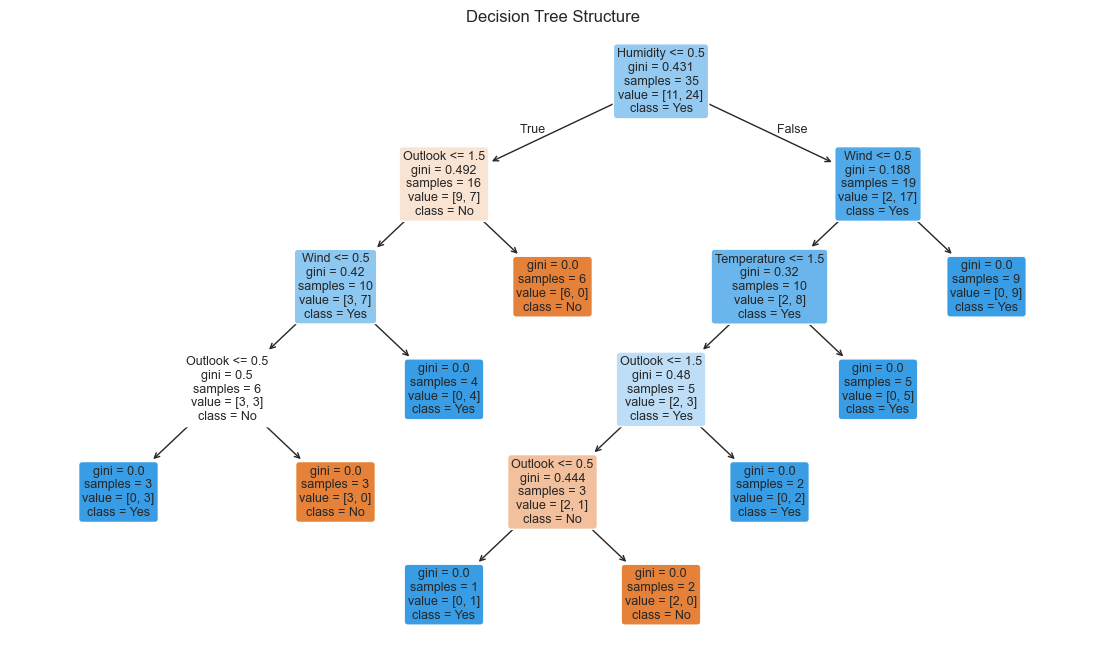

In [15]:
plt.figure(figsize=(14, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=dt_model.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Structure")
plt.show()